In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('fake_reg.csv ')

In [4]:
df.head()

,price,feature1,feature2
0,461.527929,999.787558,999.766096
1,548.130011,998.861615,1001.042403
2,410.297162,1000.070267,998.844015
3,540.382220,999.952251,1000.440940
4,546.024553,1000.446011,1000.338531


## Explore the data

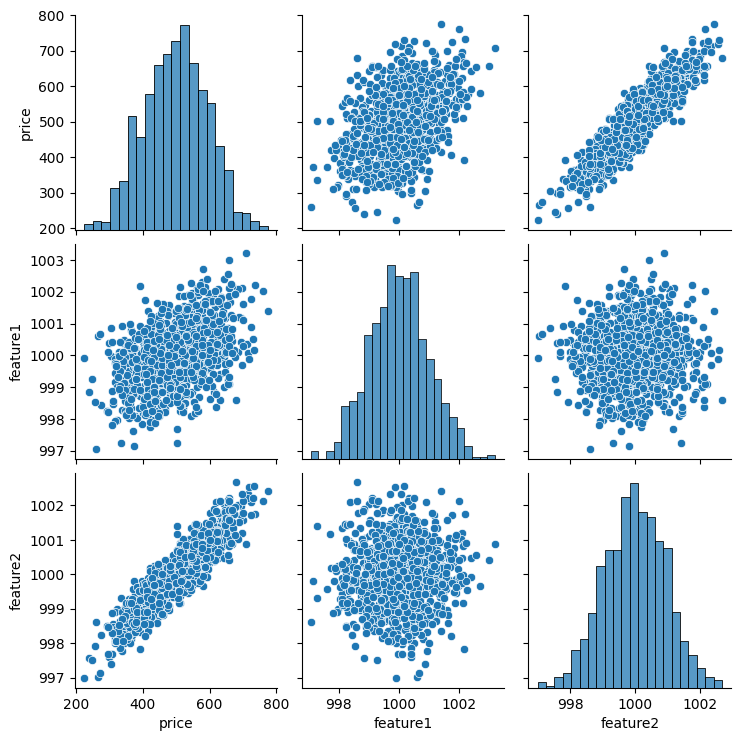

In [5]:
sns.pairplot(df)

## Train test split

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X = df[['feature1','feature2']].values
y =df['price'].values

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [9]:
X_train.shape

(700, 2)

In [10]:
X_test.shape

(300, 2)

## Normalizing/Scalling the Data

In [11]:
from sklearn.preprocessing import MinMaxScaler

In [12]:
scaler = MinMaxScaler()
scaler.fit(X_train)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [13]:
X_train = scaler.transform(X_train)

In [14]:
X_test = scaler.transform(X_test)

## Tensorflow Syntax

In [15]:
import tensorflow as tf

In [16]:
from keras.models import Sequential
from keras.layers import Dense

In [18]:
help(Sequential)

Help on class Sequential in module keras.src.models.sequential:

class Sequential(keras.src.models.model.Model)
 |  Sequential(*args, **kwargs)
 |
 |  `Sequential` groups a linear stack of layers into a `Model`.
 |
 |  Examples:
 |
 |  ```python
 |  model = keras.Sequential()
 |  model.add(keras.Input(shape=(16,)))
 |  model.add(keras.layers.Dense(8))
 |
 |  # Note that you can also omit the initial `Input`.
 |  # In that case the model doesn't have any weights until the first call
 |  # to a training/evaluation method (since it isn't yet built):
 |  model = keras.Sequential()
 |  model.add(keras.layers.Dense(8))
 |  model.add(keras.layers.Dense(4))
 |  # model.weights not created yet
 |
 |  # Whereas if you specify an `Input`, the model gets built
 |  # continuously as you are adding layers:
 |  model = keras.Sequential()
 |  model.add(keras.Input(shape=(16,)))
 |  model.add(keras.layers.Dense(8))
 |  len(model.weights)  # Returns "2"
 |
 |  # When using the delayed-build pattern (no 

## Creating a model
There are two ways to create models through the TF 2 Keras API, either pass in a list of layers all at once, or add them one by one.

In [19]:
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense

# print("TensorFlow version:", tf.__version__)

In [20]:
from keras.models import Sequential
from keras.layers import Dense, Activation

## Model - as a list of layers

In [21]:
model = Sequential([Dense(4),
                    Dense(4),
                    Dense(1)])

### Model - adding in layers one by one

In [22]:
model = Sequential()

model.add(Dense(2))
model.add(Dense(2))
model.add(Dense(2))

Let's go ahead and build a simple model and then compile it by defining our solver

In [23]:
model = Sequential()
model.add(Dense(4, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(1))

In [24]:
model.compile(optimizer='rmsprop', loss='mse')

### Choosing an optimizer and loss

Keep in mind what kind of problem you are trying to solve:

    # For a multi-class classification problem
    model.compile(optimizer='rmsprop',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # For a binary classification problem
    model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    # For a mean squared error regression problem
    model.compile(optimizer='rmsprop',
                  loss='mse')

In [25]:
model.fit(X_train, y_train, epochs=250)

Epoch 1/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 256813.4688
Epoch 2/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 256527.9375 
Epoch 3/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 256350.8750 
Epoch 4/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 256156.0938
Epoch 5/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 255913.0000
Epoch 6/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 255599.1250 
Epoch 7/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 255256.5781 
Epoch 8/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 254873.7188 
Epoch 9/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 254442.3750 
Epoch 10/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 253955.3438 
Epoch 11/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 253403.4531 
Epoch 12/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 252785.9219
Epoch 13/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 252094.4688
Epoch 14/250
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 25131

## Evaluation

Let's evaluate our performance on our training set and our test set. We can compare these two performances to check for overfitting.

In [28]:
model.history.history

{'loss': [256813.46875,
  256527.9375,
  256350.875,
  256156.09375,
  255913.0,
  255599.125,
  255256.578125,
  254873.71875,
  254442.375,
  253955.34375,
  253403.453125,
  252785.921875,
  252094.46875,
  251311.890625,
  250443.859375,
  249479.859375,
  248413.671875,
  247237.484375,
  245953.1875,
  244546.765625,
  243011.65625,
  241342.671875,
  239529.875,
  237567.71875,
  235469.71875,
  233209.234375,
  230791.0,
  228187.3125,
  225407.640625,
  222464.75,
  219336.828125,
  215994.46875,
  212470.40625,
  208759.640625,
  204845.828125,
  200709.09375,
  196398.03125,
  191866.15625,
  187113.25,
  182164.484375,
  177020.921875,
  171689.765625,
  166137.125,
  160395.5625,
  154465.96875,
  148372.5,
  142068.421875,
  135618.75,
  129033.03125,
  122335.015625,
  115489.390625,
  108592.03125,
  101606.9140625,
  94536.78125,
  87430.2265625,
  80314.9921875,
  73167.015625,
  66056.796875,
  59071.296875,
  52231.984375,
  45557.2265625,
  39141.78125,
  33062.296

In [29]:
loss = model.history.history['loss']

Text(0.5, 1.0, 'Loss per Epochs')

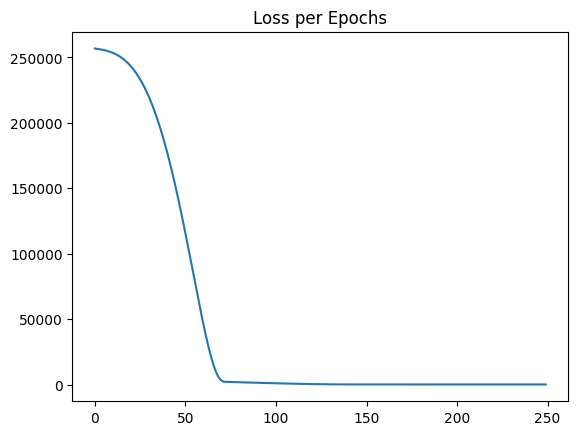

In [30]:
sns.lineplot(x=range(len(loss)), y=loss)
plt.title('Loss per Epochs')

## Comparing Final evaluation (MSE) on training set and test set

In [31]:
model.metrics_names

['loss']

In [32]:
training_score = model.evaluate(X_train, y_train, verbose=0)
test_score = model.evaluate(X_test, y_test, verbose=0)

In [33]:
training_score

23.91116714477539

In [34]:
test_score

25.80417823791504

## Further Evaluation

In [56]:
test_predictions = model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  


In [57]:
test_predictions

array([[405.4512 ],
       [624.13745],
       [592.665  ],
       [572.72565],
       [366.70868],
       [579.68964],
       [515.4414 ],
       [459.3737 ],
       [549.69855],
       [447.7621 ],
       [612.36005],
       [549.38666],
       [419.28967],
       [409.04037],
       [651.8869 ],
       [437.52264],
       [508.8136 ],
       [660.6092 ],
       [663.2625 ],
       [566.01636],
       [334.25125],
       [445.07507],
       [382.64557],
       [378.8632 ],
       [567.08   ],
       [611.16864],
       [532.8078 ],
       [428.0663 ],
       [656.1109 ],
       [414.25766],
       [442.86954],
       [485.4493 ],
       [438.64175],
       [682.5667 ],
       [424.95334],
       [417.87607],
       [502.2739 ],
       [550.9269 ],
       [510.11026],
       [395.50662],
       [619.1778 ],
       [416.81052],
       [605.008  ],
       [446.19748],
       [502.34445],
       [582.2219 ],
       [669.6839 ],
       [490.73178],
       [318.5638 ],
       [485.75012],


In [58]:
pred_df = pd.DataFrame(y_test, columns=['Test Y'])
pred_df

,Test Y
0,402.296319
1,624.156198
2,582.455066
3,578.588606
4,371.224104
...,...
295,525.704657
296,502.909473
297,612.727910
298,417.569725


In [59]:
test_predictions = pd.Series(test_predictions.reshape(300,))
test_predictions

0      405.451202
1      624.137451
2      592.664978
3      572.725647
4      366.708679
          ...    
295    529.457458
296    515.726013
297    610.220825
298    417.136078
299    411.051544
Length: 300, dtype: float32

In [60]:
pred_df = pd.concat([pred_df, test_predictions], axis=1)
pred_df.columns = ['Test Y', 'Model Predictions']

In [61]:
pred_df

,Test Y,Model Predictions
0,402.296319,405.451202
1,624.156198,624.137451
2,582.455066,592.664978
3,578.588606,572.725647
4,371.224104,366.708679
...,...,...
295,525.704657,529.457458
296,502.909473,515.726013
297,612.727910,610.220825
298,417.569725,417.136078


<Axes: xlabel='Test Y', ylabel='Model Predictions'>

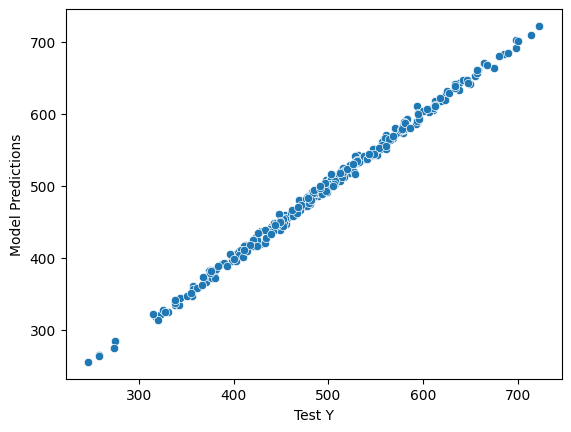

In [62]:
sns.scatterplot(x='Test Y', y='Model Predictions', data=pred_df)

In [63]:
pred_df['error'] = pred_df['Test Y'] - pred_df['Model Predictions']

In [65]:
pred_df

,Test Y,Model Predictions,error
0,402.296319,405.451202,-3.154884
1,624.156198,624.137451,0.018747
2,582.455066,592.664978,-10.209912
3,578.588606,572.725647,5.862959
4,371.224104,366.708679,4.515424
...,...,...,...
295,525.704657,529.457458,-3.752802
296,502.909473,515.726013,-12.816540
297,612.727910,610.220825,2.507085
298,417.569725,417.136078,0.433647


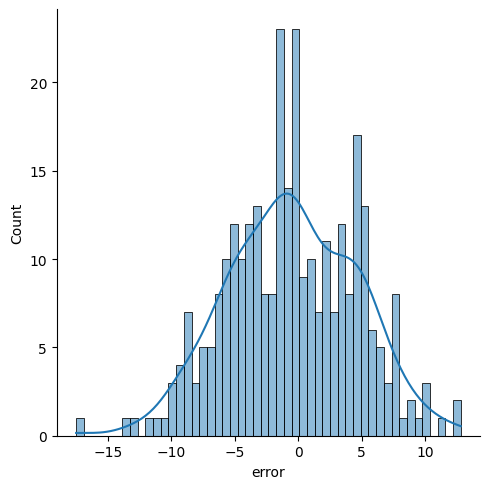

In [70]:
sns.displot(pred_df['error'], bins=50, kde=True)

In [71]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [72]:
mean_absolute_error(pred_df['Test Y'], pred_df['Model Predictions'])

4.095221033974121

In [73]:
mean_squared_error(pred_df['Test Y'], pred_df['Model Predictions'])

25.80418258055627

In [ ]:
# RSME
test_score**0.5

5.079781317922558

## Predicting brand new data

In [83]:
#new gem
new_gem = [998,1000]

In [ ]:
#Transform the new gem using the same scaler that was fitted on the training data. 
# This ensures that the new data is scaled in the same way as the training data, allowing for accurate predictions from the model.
scaler.transform([new_gem])

array([[0.14117652, 0.53968792]])

In [85]:
new_gem = scaler.transform([new_gem])

In [86]:
model.predict(new_gem)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


array([[419.8843]], dtype=float32)

## Saving and Load the Model

In [87]:
from keras.models import load_model

In [94]:
model.save('my_gem_model.keras')

In [95]:
later_model = load_model('my_gem_model.keras')

In [96]:
later_model.predict(new_gem)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step


array([[419.8843]], dtype=float32)